# Project ResNet Ablation Study (Residual Model)

### ResNet-34, ResNet-50 모델 구현이 정상적으로 진행되었는가?

### 구현한 ResNet 모델을 활용하여 Image Classification 모델 훈련이 가능한가?

### Ablation Study 결과가 바른 포맷으로 제출되었는가?

| Model | Train Accuracy | Validation Accuracy |
| --- | --- | --- |
| ResNet-34 (Plain) | 92.21% | 87.02% |
| ResNet-50 (Residual) | 87.70% | 83.34% |

| Normalization | Mean | Std | Purpose |
| --- | --- | --- | --- |
| CIFAR-10 stats | (0.4914, 0.4822, 0.4465) | (0.2023, 0.1994, 0.2010) | Best practice, dataset-specific normalization |
| Generic (0.5,0.5,0.5) | (0.5, 0.5, 0.5) | (0.5, 0.5, 0.5) | Simple scaling to [-1,1], less precise |

In [ ]:
!nvidia-smi

Sun Jul 26 20:42:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.62                 KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   60C    P0             47W /   60W |    3857MiB /   4096MiB |     92%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch, torchvision
print(torch.__version__)
print(torchvision.__version__)
print(torch.cuda.is_available())  # True면 GPU 사용 가능

2.13.0+cu132
0.28.0+cu132
True


In [ ]:
# import importlib
# import subprocess
# import sys
import os
# from google.colab import drive

# # Install and import torchinfo
# def install_and_import(package):
#     try:
#         return importlib.import_module(package)
#     except ImportError:
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package])
#         return importlib.import_module(package)

# install_and_import("torchinfo")

# # Google Drive Mount
# # Check if /content/drive exists
# if not os.path.exists('/content/drive'): drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/Colab Notebooks')

# CIFAR-10 path
data_path = './data'
train_path = os.path.join(data_path, 'cifar-10-batches-py')

# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
BATCH_SIZE = 256
EPOCH = 30  # [CHANGED] Increased epochs from 15 to 30 to give the model more time to learn.
            # This helps the network converge better on CIFAR-10, which is a non-trivial dataset.

In [ ]:
# Data preparation (CIFAR-10 example)
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

#########################################################################################################################
## Is path exists? If not, download the dataset
download_flag = not os.path.exists(train_path)
trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=download_flag, transform=transform)
testset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=download_flag, transform=transform)

# # Download CIFAR-10 dataset
# # Way 1
# trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# # Way 2 Manually download the dataset from https://www.cs.toronto.edu/~kriz/cifar.html and extract it to the data folder
# !mkdir -p data
# !wget --no-check-certificate https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -O ./data/cifar-10-python.tar.gz
# !cd data && tar -xzf cifar-10-python.tar.gz
##########################################################################################################################

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


In [ ]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [ ]:
# Q. 이미지의 표현이 0과 1 사이로 들어오도록 직접 Pytorch 정규화 코드를 작성해봅시다.
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

In [ ]:
num_classes = len(trainset.classes)
print(num_classes)

10


In [ ]:
class_names = trainset.classes
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# Helper function to unnormalize and show an image
def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))  # CHW -> HWC
    mean = np.array([0.4914, 0.4822, 0.4465])     # CIFAR-10 mean
    std = np.array([0.2023, 0.1994, 0.2010])      # CIFAR-10 std
    img = std * img + mean                        # unnormalize
    img = np.clip(img, 0, 1)                      # clip to valid range
    return img

In [ ]:
def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])   # unnormalize before plotting
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

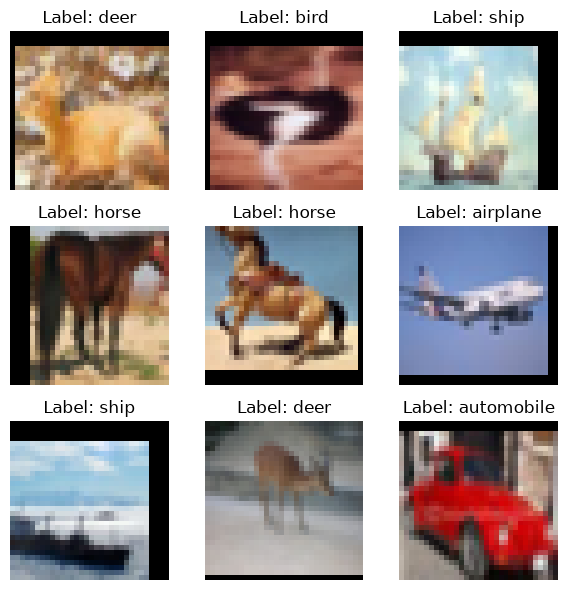

In [ ]:
# Show 9 training images
show_multiple_images(trainloader)

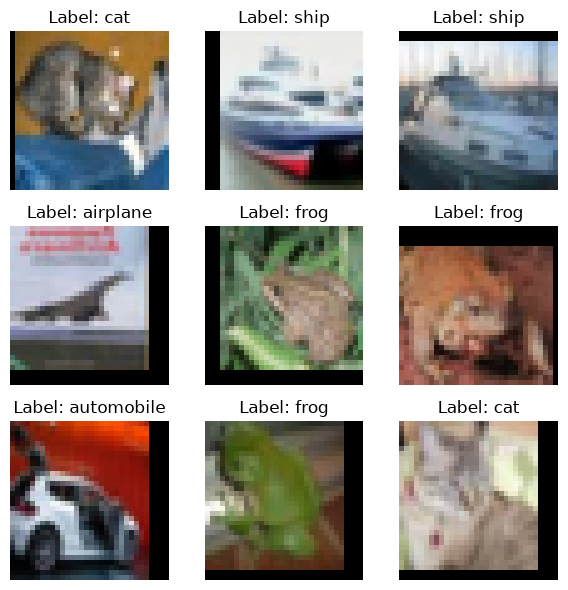

In [ ]:
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

In [ ]:
# -------------------------------
# Basic Residual Block (used in ResNet-18/34)
# -------------------------------
class BasicBlock(nn.Module):
    expansion = 1  # Output channel multiplier

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        # First convolution layer
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Second convolution layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Downsample layer (used when dimensions change)
        self.downsample = downsample

    def forward(self, x):
        identity = x  # Save input for residual connection

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Add residual connection
        out += identity
        out = self.relu(out)

        return out

# -------------------------------
# Bottleneck Block (used in ResNet-50/101/152)
# -------------------------------
class Bottleneck(nn.Module):
    expansion = 4  # Output channel multiplier

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # 1x1 convolution (reduce dimensions)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 3x3 convolution (main processing)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1 convolution (expand dimensions)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x  # Save input for residual connection

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # Add residual connection
        out += identity
        out = self.relu(out)

        return out

# -------------------------------
# ResNet Class (general structure)
# -------------------------------
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # [CHANGED] Initial convolution adapted for CIFAR-10 (32x32 images).
        # - Changed kernel_size from 7 to 3.
        # - Changed stride from 2 to 1.
        # - Kept padding=1 to preserve spatial resolution.
        # This prevents overly aggressive downsampling at the very beginning,
        # which is appropriate for small images like CIFAR-10.
        self.conv1 = nn.Conv2d(
            3, 64,
            kernel_size=3,  # was 7 for ImageNet
            stride=1,       # was 2 for ImageNet
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # [CHANGED] Removed initial max pooling for CIFAR-10.
        # Using MaxPool2d with stride=2 right after the first conv would shrink
        # 32x32 images too quickly, harming performance.
        # Replaced with nn.Identity() to keep the feature map size unchanged.
        self.maxpool = nn.Identity()

        # Residual layers (4 stages) remain the same.
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Global average pooling + fully connected classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    # Helper function to build each residual layer
    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        # If dimensions change, create downsample layer
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        # First block may require downsampling
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        # Remaining blocks
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Classification head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# -------------------------------
# Build specific ResNet variants
# -------------------------------
def build_resnet34(num_classes=10):
    # ResNet-34 uses BasicBlock
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes)

def build_resnet50(num_classes=10):
    # ResNet-50 uses Bottleneck
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes)

In [ ]:
# ResNet-34
resnet_34 = build_resnet34()
# [CHANGED] Input size changed from (1, 3, 224, 224) to (1, 3, 32, 32) for CIFAR-10.
summary(resnet_34, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,728
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─Identity: 1-4                          [1, 64, 32, 32]           --
├─Sequential: 1-5                        [1, 64, 32, 32]           --
│    └─BasicBlock: 2-1                   [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 32, 32]           128
│    │    └─ReLU: 3-3                    [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-4                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 32, 32]           128
│    │    └─ReLU: 3-6                    [1, 64, 32, 32]           --
│

In [ ]:
# ResNet-50
resnet_50 = build_resnet50()
# [CHANGED] Same adjustment for ResNet-50 to reflect CIFAR-10 image size.
summary(resnet_50, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,728
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─Identity: 1-4                          [1, 64, 32, 32]           --
├─Sequential: 1-5                        [1, 256, 32, 32]          --
│    └─Bottleneck: 2-1                   [1, 256, 32, 32]          --
│    │    └─Sequential: 3-1              [1, 256, 32, 32]          16,896
│    │    └─Conv2d: 3-2                  [1, 64, 32, 32]           4,096
│    │    └─BatchNorm2d: 3-3             [1, 64, 32, 32]           128
│    │    └─ReLU: 3-4                    [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-6             [1, 64, 32, 32]           12

In [ ]:
# -------------------------------
# Test ResNet-34
# -------------------------------
resnet34 = build_resnet34(num_classes=10)
print(resnet34)

# [CHANGED] Dummy input size adapted to CIFAR-10 (32x32) instead of ImageNet (224x224).
dummy_input = torch.zeros(1, 3, 32, 32)
output = resnet34(dummy_input)
print("ResNet-34 output shape:", output.shape)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(

In [ ]:
# -------------------------------
# Test ResNet-50
# -------------------------------
resnet50 = build_resnet50(num_classes=10)   # CIFAR-10 has 10 classes
print(resnet50)                             # Print model architecture

# [CHANGED] Same dummy input size change for ResNet-50.
dummy_input = torch.zeros(1, 3, 32, 32)
output = resnet50(dummy_input)
print("ResNet-50 output shape:", output.shape)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    

In [ ]:
# Record the start time to measure training duration
current_time = time.time()

# Select device: use GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model: ResNet34 adapted for CIFAR-10 (10 classes)
resnet34 = build_resnet34(num_classes=10).to(device)

# Define loss function: CrossEntropyLoss is standard for classification tasks
criterion = nn.CrossEntropyLoss()

# Define optimizer: Stochastic Gradient Descent with momentum and weight decay
optimizer = optim.SGD(
    resnet34.parameters(),
    lr=0.1,              # [UNCHANGED] Initial learning rate kept at 0.1,
                         # which is common for ResNet on CIFAR-10.
    momentum=0.9,
    weight_decay=1e-4
)

# [ADDED] Learning rate scheduler to improve convergence.
# MultiStepLR reduces the learning rate at specific epochs (milestones),
# helping the model refine its weights after the initial fast learning phase.
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[15, 25],  # epochs at which LR will be reduced
    gamma=0.1             # factor by which LR is multiplied
)

# Lists to store training loss and validation accuracy per epoch
resnet34_train_losses = []
resnet34_val_accuracy = []

# Training loop across epochs
for epoch in range(EPOCH):
    resnet34.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Iterate over training batches
    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()               # Reset gradients
        outputs = resnet34(inputs)          # Forward pass
        loss = criterion(outputs, labels)   # Compute loss
        loss.backward()                     # Backpropagation
        optimizer.step()                    # Update weights

        # Track training loss and accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)  # Get predicted class
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    # [ADDED] Step the scheduler once per epoch to update the learning rate.
    scheduler.step()

    # Compute average training loss and accuracy
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    resnet34_train_losses.append(train_loss)
    print(f"Epoch {epoch+1}: Train Accuracy: {train_acc:.2f}%")

    # -------------------------------
    # Validation phase
    # -------------------------------
    resnet34.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet34(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Compute validation accuracy
    val_acc = 100 * correct / total
    resnet34_val_accuracy.append(val_acc)
    print(f"Epoch {epoch+1}: Validation Accuracy: {val_acc:.2f}%")

# -------------------------------
# End of training
# -------------------------------
print("Finished Training")
print("Elapsed time:", time.time() - current_time)


[1,   100] loss: 3.700
Epoch 1: Train Accuracy: 20.35%
Epoch 1: Validation Accuracy: 30.95%
[2,   100] loss: 2.836
Epoch 2: Train Accuracy: 34.56%
Epoch 2: Validation Accuracy: 37.18%
[3,   100] loss: 2.613
Epoch 3: Train Accuracy: 42.60%
Epoch 3: Validation Accuracy: 45.52%
[4,   100] loss: 2.441
Epoch 4: Train Accuracy: 48.61%
Epoch 4: Validation Accuracy: 47.98%
[5,   100] loss: 2.298
Epoch 5: Train Accuracy: 54.63%
Epoch 5: Validation Accuracy: 57.00%
[6,   100] loss: 2.143
Epoch 6: Train Accuracy: 60.68%
Epoch 6: Validation Accuracy: 62.33%
[7,   100] loss: 2.009
Epoch 7: Train Accuracy: 65.10%
Epoch 7: Validation Accuracy: 56.40%
[8,   100] loss: 1.922
Epoch 8: Train Accuracy: 68.44%
Epoch 8: Validation Accuracy: 67.86%
[9,   100] loss: 1.821
Epoch 9: Train Accuracy: 71.62%
Epoch 9: Validation Accuracy: 71.07%
[10,   100] loss: 1.758
Epoch 10: Train Accuracy: 73.84%
Epoch 10: Validation Accuracy: 73.73%
[11,   100] loss: 1.694
Epoch 11: Train Accuracy: 75.98%
Epoch 11: Validation

In [ ]:
# Record the start time to measure training duration
current_time = time.time()

# Select device: use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# Model, loss function, optimizer
# -------------------------------
resnet50 = build_resnet50(num_classes=10).to(device)   # CIFAR-10 has 10 classes
criterion = nn.CrossEntropyLoss()                      # Standard classification loss
optimizer = optim.SGD(
    resnet50.parameters(),
    lr=0.1,              # [UNCHANGED] Same initial LR as ResNet-34.
    momentum=0.9,
    weight_decay=1e-4
)

# [ADDED] Learning rate scheduler for ResNet-50 as well.
scheduler50 = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[15, 25],
    gamma=0.1
)

# Lists to store training loss and validation accuracy per epoch
resnet50_train_losses = []
resnet50_val_accuracy = []

# -------------------------------
# Training loop across epochs
# -------------------------------
for epoch in range(EPOCH):
    resnet50.train()   # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Iterate over training batches
    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()                # Reset gradients
        outputs = resnet50(inputs)           # Forward pass
        loss = criterion(outputs, labels)    # Compute loss
        loss.backward()                      # Backpropagation
        optimizer.step()                     # Update weights

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)   # Get predicted class
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    # [ADDED] Step the scheduler for ResNet-50.
    scheduler50.step()

    # Compute average training loss and accuracy
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    resnet50_train_losses.append(train_loss)

    print(f"Epoch {epoch+1}: Train Accuracy: {train_acc:.2f}%")

    # -------------------------------
    # Validation phase
    # -------------------------------
    resnet50.eval()   # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():   # Disable gradient computation
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet50(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Compute validation accuracy

    val_acc = 100 * correct / total
    resnet50_val_accuracy.append(val_acc)
    print(f"Epoch {epoch+1}: Validation Accuracy: {val_acc:.2f}%")

# -------------------------------
# End of training
# -------------------------------
print("Finished Training")
print("Elapsed time:", time.time() - current_time)

[1,   100] loss: 4.700
Epoch 1: Train Accuracy: 11.55%
Epoch 1: Validation Accuracy: 16.75%
[2,   100] loss: 3.065
Epoch 2: Train Accuracy: 22.38%
Epoch 2: Validation Accuracy: 26.03%
[3,   100] loss: 2.846
Epoch 3: Train Accuracy: 31.89%
Epoch 3: Validation Accuracy: 36.76%
[4,   100] loss: 2.688
Epoch 4: Train Accuracy: 38.04%
Epoch 4: Validation Accuracy: 40.02%
[5,   100] loss: 2.560
Epoch 5: Train Accuracy: 43.87%
Epoch 5: Validation Accuracy: 44.72%
[6,   100] loss: 2.437
Epoch 6: Train Accuracy: 48.38%
Epoch 6: Validation Accuracy: 50.08%
[7,   100] loss: 2.317
Epoch 7: Train Accuracy: 53.52%
Epoch 7: Validation Accuracy: 56.35%
[8,   100] loss: 2.208
Epoch 8: Train Accuracy: 58.27%
Epoch 8: Validation Accuracy: 59.46%
[9,   100] loss: 2.069
Epoch 9: Train Accuracy: 62.70%
Epoch 9: Validation Accuracy: 63.99%
[10,   100] loss: 1.978
Epoch 10: Train Accuracy: 66.54%
Epoch 10: Validation Accuracy: 64.24%
[11,   100] loss: 1.885
Epoch 11: Train Accuracy: 69.35%
Epoch 11: Validation

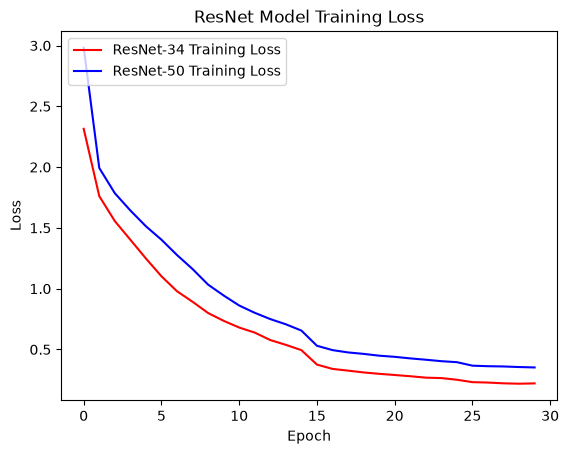

In [ ]:
plt.plot(resnet34_train_losses, 'r', label="ResNet-34 Training Loss")
plt.plot(resnet50_train_losses, 'b', label="ResNet-50 Training Loss")

plt.title('ResNet Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

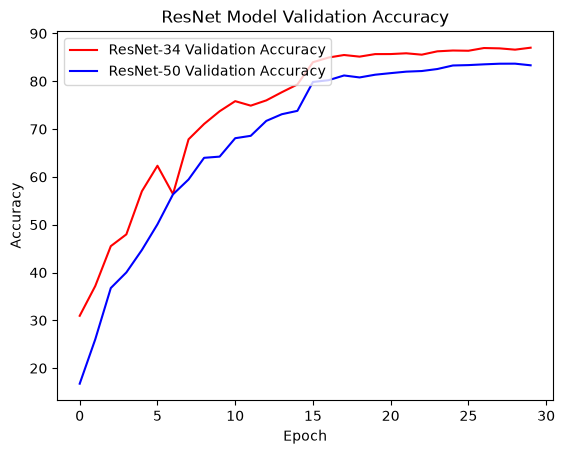

In [ ]:
plt.plot(resnet34_val_accuracy, 'r', label="ResNet-34 Validation Accuracy")
plt.plot(resnet50_val_accuracy, 'b', label="ResNet-50 Validation Accuracy")

plt.title('ResNet Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()